In [76]:
%pip install geojson
import pandas as pd
import geojson
import pandas as pd
import altair as alt
import json
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
%pip install vl-convert-python
import altair as alt
alt.renderers.enable('png')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 22.3 MB/s eta 0:00:00


RendererRegistry.enable('png')

In [77]:
df3=pd.read_csv("/content/drive/MyDrive/DATA SCIENCE/Data Ethics/df3c.csv")

In [78]:
import statsmodels.formula.api as smf
model=smf.ols('Q("Fare") ~ Q("Trip Miles") + Q("Trip Minutes")+C(hour)+C(day)+ is_holiday + midway_pick + midway_drop + ohare_pick + ohare_drop', data=df3).fit(cov_type='cluster', cov_kwds={'groups': df3['Pickup Community Area']})
print(model.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 36, but rank is 35
  warnings.warn('covariance of constraints does not have full '


                            OLS Regression Results                            
Dep. Variable:              Q("Fare")   R-squared:                       0.663
Model:                            OLS   Adj. R-squared:                  0.663
Method:                 Least Squares   F-statistic:                 1.004e+04
Date:                Fri, 22 May 2026   Prob (F-statistic):          2.02e-126
Time:                        20:24:02   Log-Likelihood:            -1.1804e+07
No. Observations:             3751383   AIC:                         2.361e+07
Df Residuals:                 3751346   BIC:                         2.361e+07
Df Model:                          36                                         
Covariance Type:              cluster                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               8.9490    

In [79]:
df3['residuals']=df3['Fare']-model.predict(df3)

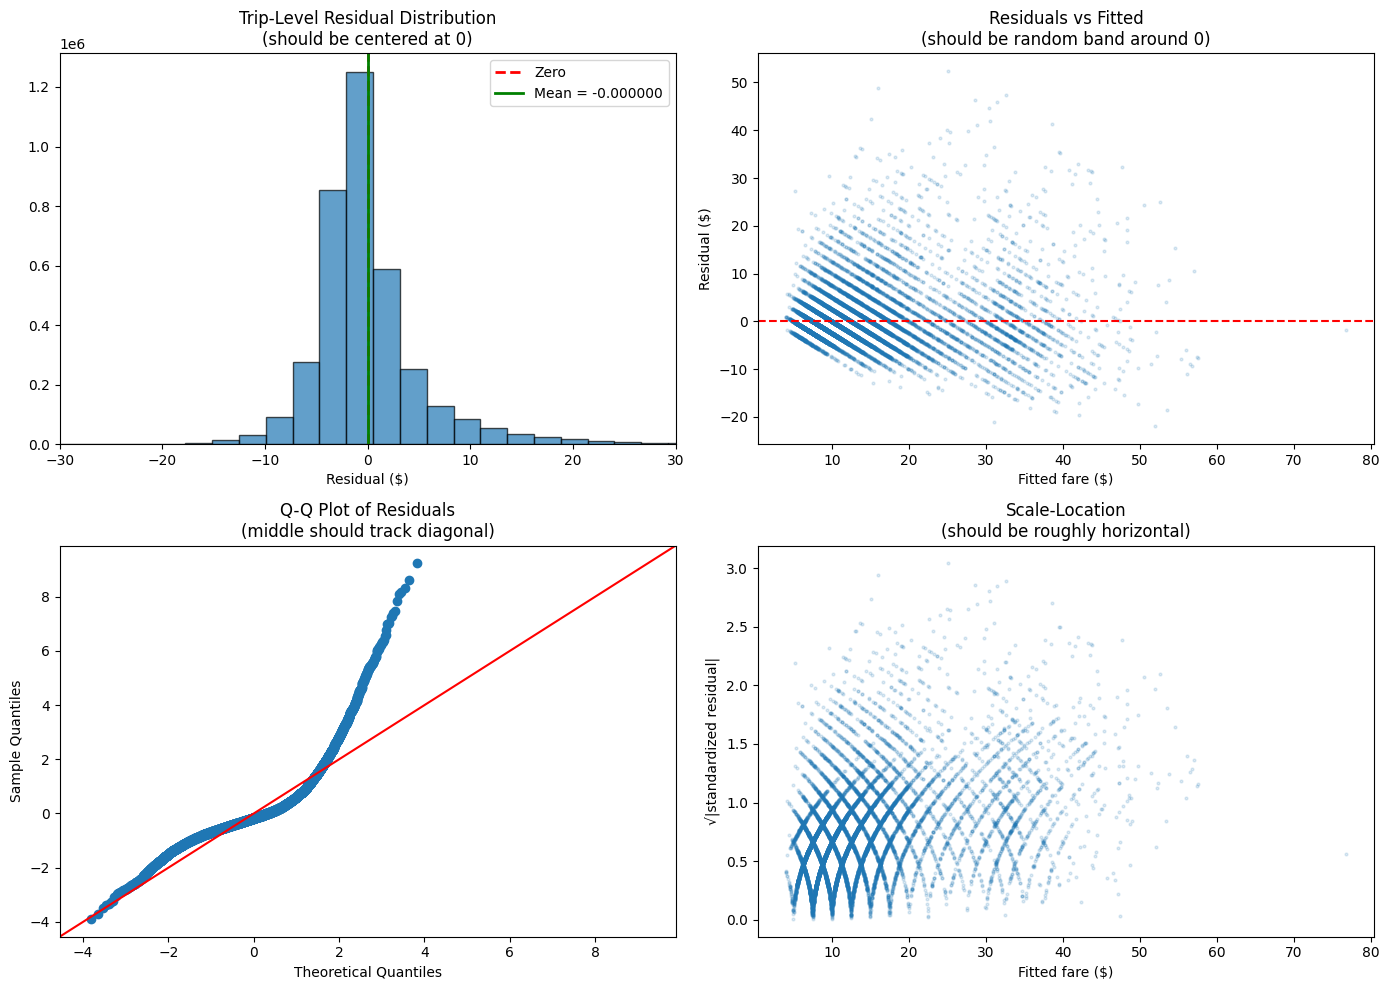

In [80]:
# Sample for plotting
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(df3), 15000, replace=False)
resid_sample = model.resid.iloc[sample_idx]
fitted_sample = model.fittedvalues.iloc[sample_idx]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

#1 Trip-level residual distribution — top-left
mean_resid = model.resid.mean()
axes[0, 0].hist(model.resid, bins=100, edgecolor='black', alpha=0.7)
axes[0, 0].axvline(0, color='red', linestyle='--', linewidth=2, label='Zero')
axes[0, 0].axvline(mean_resid, color='green', linestyle='-', linewidth=2,
                   label=f'Mean = {mean_resid:.6f}')
axes[0, 0].set_xlim(-30, 30)
axes[0, 0].set_xlabel('Residual ($)')
axes[0, 0].set_title('Trip-Level Residual Distribution\n(should be centered at 0)')
axes[0, 0].legend()

#2 Residuals vs Fitted — top-right
axes[0, 1].scatter(fitted_sample, resid_sample, alpha=0.15, s=4)
axes[0, 1].axhline(0, color='red', linestyle='--')
axes[0, 1].set_xlabel('Fitted fare ($)')
axes[0, 1].set_ylabel('Residual ($)')
axes[0, 1].set_title('Residuals vs Fitted\n(should be random band around 0)')

#3 Q-Q Plot — bottom-left
sm.qqplot(resid_sample, line='45', fit=True, ax=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot of Residuals\n(middle should track diagonal)')

#4 Scale-Location — bottom-right
std_resid_sample = np.sqrt(np.abs(resid_sample / resid_sample.std()))
axes[1, 1].scatter(fitted_sample, std_resid_sample, alpha=0.15, s=4)
axes[1, 1].set_xlabel('Fitted fare ($)')
axes[1, 1].set_ylabel('√|standardized residual|')
axes[1, 1].set_title('Scale-Location\n(should be roughly horizontal)')

plt.tight_layout()
plt.show()

- Residuals kind of centered along zero
- Follows the 45 degree line up to middle then goes up
- heteroschedasticity - some extreme overpriced trips but makes sense given that surging prices exist

### Chicago Map

In [81]:
with open("/content/drive/MyDrive/DATA SCIENCE/Data Ethics/Project Data Ethics/Boundaries_-_Community_Areas_20260512.geojson") as f:
    chi_map = geojson.load(f)


In [82]:
chicago_ca_df = pd.read_json("/content/drive/MyDrive/DATA SCIENCE/Data Ethics/Project Data Ethics/Boundaries_-_Community_Areas_20260512.geojson")

display(chicago_ca_df.head(1))
print('\nKeys in features:')
display(chicago_ca_df.loc[0].features.keys())
print("\nKeys in features['properties']:")
display(chicago_ca_df.loc[0].features['properties'].keys())

print('\nEach row should have a type=Feature, a geometry, and a ca identifier:')
chicago_ca_df['type'] = chicago_ca_df.features.apply(lambda x: x['type']) # Required!
chicago_ca_df['geometry'] = chicago_ca_df.features.apply(lambda x: x['geometry'])
chicago_ca_df['community_area'] = chicago_ca_df.features.apply(lambda x: x['properties']['area_numbe'])
chicago_ca_df['community_area']=chicago_ca_df['community_area'].astype(float)
chicago_ca_df['community_area_name'] = chicago_ca_df.features.apply(lambda x: x['properties']['community'])

display(chicago_ca_df.head())

,type,features
0,FeatureCollection,"{'type': 'Feature', 'geometry': {'type': 'Mult..."



Keys in features:


dict_keys(['type', 'geometry', 'properties'])


Keys in features['properties']:


dict_keys([':id', ':version', ':created_at', ':updated_at', 'area_numbe', 'community', 'area_num_1', 'shape_area', 'shape_len'])


Each row should have a type=Feature, a geometry, and a ca identifier:


,type,features,geometry,community_area,community_area_name
0,Feature,"{'type': 'Feature', 'geometry': {'type': 'Mult...","{'type': 'MultiPolygon', 'coordinates': [[[[-8...",1.0,ROGERS PARK
1,Feature,"{'type': 'Feature', 'geometry': {'type': 'Mult...","{'type': 'MultiPolygon', 'coordinates': [[[[-8...",2.0,WEST RIDGE
2,Feature,"{'type': 'Feature', 'geometry': {'type': 'Mult...","{'type': 'MultiPolygon', 'coordinates': [[[[-8...",3.0,UPTOWN
3,Feature,"{'type': 'Feature', 'geometry': {'type': 'Mult...","{'type': 'MultiPolygon', 'coordinates': [[[[-8...",4.0,LINCOLN SQUARE
4,Feature,"{'type': 'Feature', 'geometry': {'type': 'Mult...","{'type': 'MultiPolygon', 'coordinates': [[[[-8...",5.0,NORTH CENTER


## Residuals

In [83]:
pickupresiduals=df3.groupby('Pickup Community Area')['residuals'].agg(mean_total='mean', median_total='median', count='count').reset_index().rename(columns={'Pickup Community Area': 'community_area'})
dropoffresiduals=df3.groupby('Dropoff Community Area')['residuals'].agg(mean_total='mean', median_total='median', count='count').reset_index().rename(columns={'Dropoff Community Area': 'community_area'})

mergedRp=chicago_ca_df.merge(pickupresiduals, on='community_area')
mergedRd=chicago_ca_df.merge(dropoffresiduals, on='community_area')


mergedRp.head()

,type,features,geometry,community_area,community_area_name,mean_total,median_total,count
0,Feature,"{'type': 'Feature', 'geometry': {'type': 'Mult...","{'type': 'MultiPolygon', 'coordinates': [[[[-8...",1.0,ROGERS PARK,-2.028535,-2.156558,38080
1,Feature,"{'type': 'Feature', 'geometry': {'type': 'Mult...","{'type': 'MultiPolygon', 'coordinates': [[[[-8...",2.0,WEST RIDGE,-2.368218,-2.231300,21017
2,Feature,"{'type': 'Feature', 'geometry': {'type': 'Mult...","{'type': 'MultiPolygon', 'coordinates': [[[[-8...",3.0,UPTOWN,-0.611453,-1.250923,98861
3,Feature,"{'type': 'Feature', 'geometry': {'type': 'Mult...","{'type': 'MultiPolygon', 'coordinates': [[[[-8...",4.0,LINCOLN SQUARE,-1.255053,-1.521538,37771
4,Feature,"{'type': 'Feature', 'geometry': {'type': 'Mult...","{'type': 'MultiPolygon', 'coordinates': [[[[-8...",5.0,NORTH CENTER,-0.217188,-1.035693,37542


In [84]:
allresiduals=np.concatenate((mergedRp['mean_total'],mergedRd['mean_total']))

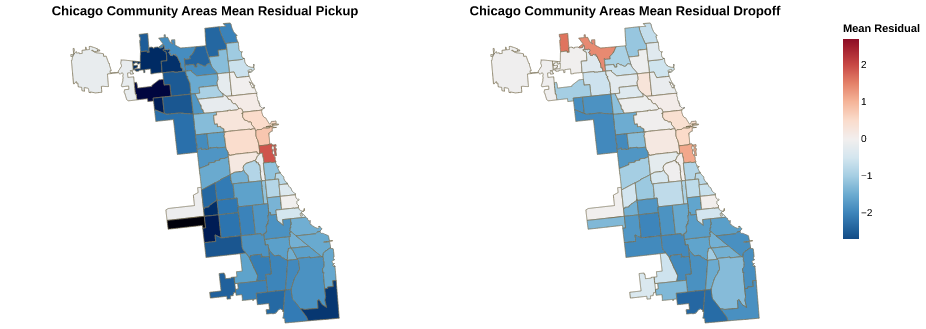

In [85]:
cap=np.nanpercentile(np.abs(allresiduals),95)

pickupresidualChart=alt.Chart(
    mergedRp,
    title="Chicago Community Areas Mean Residual Pickup").mark_geoshape( # '#2a1d0c',
    stroke='#706545',
    strokeWidth=0.75
).encode(
    alt.Color('mean_total:Q',scale=alt.Scale(scheme='redblue',domain=[-cap,cap])),
    tooltip=[
        alt.Tooltip('community_area_name:N', title='CA'),
        alt.Tooltip('mean_total:Q', title='Residual')
    ]
).properties(
    width=400
).project(
    type='albers'
)

dropoffresidualChart=alt.Chart(
    mergedRd,
    title="Chicago Community Areas Mean Residual Dropoff").mark_geoshape( # '#2a1d0c',
    stroke='#706545',
    strokeWidth=0.75
).encode(
    alt.Color('mean_total:Q',scale=alt.Scale(scheme='redblue',domain=[-cap,cap],reverse=True),
              legend=alt.Legend(title='Mean Residual')),
    tooltip=[
        alt.Tooltip('community_area_name:N', title='CA'),
        alt.Tooltip('mean_total:Q', title='Residual')
    ]
).properties(
    width=400
).project(
    type='albers'
)

pickupresidualChart | dropoffresidualChart

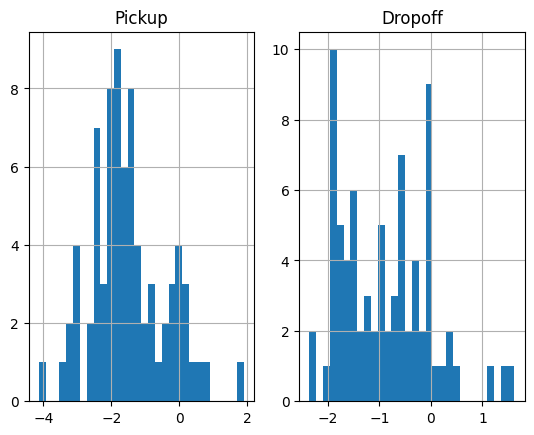

In [86]:
fig, axes = plt.subplots(1,2)
pickupresiduals['mean_total'].hist(bins=30,ax=axes[0])
axes[0].set_title('Pickup')
dropoffresiduals['mean_total'].hist(bins=30,ax=axes[1])
axes[1].set_title('Dropoff')
plt.show()
#issues with the residuals being normally distributed, or centered around 0

## ACS


In [87]:
acs=pd.read_csv("/content/drive/MyDrive/DATA SCIENCE/Data Ethics/ACS_5_Year_Data_by_Community_Area.csv")

In [88]:
acs.columns

Index(['ACS Year', 'Community Area', 'Under $25,000', '$25,000 to $49,999',
       '$50,000 to $74,999', '$75,000 to $125,000', '$125,000 +',
       'Male 0 to 17', 'Male 18 to 24', 'Male 25 to 34', 'Male 35 to 49',
       'Male 50 to 64', 'Male 65+', 'Female 0 to 17', 'Female 18 to 24',
       'Female 25 to 34', 'Female 35 to 49', 'Female 50 to 64', 'Female 65 +',
       'Total Population', 'White', 'Black or African American',
       'American Indian or Alaska Native', 'Asian',
       'Native Hawaiian or Pacific Islander', 'Other Race', 'Multiracial',
       'White Not Hispanic or Latino', 'Hispanic or Latino', 'Record ID'],
      dtype='object')

In [89]:
acs.describe()

,ACS Year,"Under $25,000","$25,000 to $49,999","$50,000 to $74,999","$75,000 to $125,000","$125,000 +",Male 0 to 17,Male 18 to 24,Male 25 to 34,Male 35 to 49,...,Total Population,White,Black or African American,American Indian or Alaska Native,Asian,Native Hawaiian or Pacific Islander,Other Race,Multiracial,White Not Hispanic or Latino,Hispanic or Latino
count,77.0,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,...,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000
mean,2023.0,987.883117,1266.155844,1005.831169,1516.000000,2566.766234,3498.558442,1616.753247,3356.662338,3522.233766,...,34384.688312,14503.012987,9903.233766,254.272727,2356.610390,17.909091,3972.870130,3376.896104,11114.142857,10170.207792
std,0.0,822.995923,993.091386,743.108184,974.685955,2565.841987,2274.594785,1245.055316,3545.974621,2642.587129,...,22483.599196,15913.453937,12622.491138,290.950151,3441.440309,34.429249,5171.590548,3285.634568,14842.603069,12238.119782
min,2023.0,31.000000,104.000000,36.000000,61.000000,34.000000,225.000000,82.000000,20.000000,87.000000,...,2186.000000,27.000000,10.000000,0.000000,0.000000,0.000000,0.000000,143.000000,18.000000,48.000000
25%,2023.0,361.000000,571.000000,441.000000,795.000000,903.000000,1786.000000,732.000000,1243.000000,1596.000000,...,18629.000000,1588.000000,1118.000000,38.000000,125.000000,0.000000,494.000000,818.000000,995.000000,1334.000000
50%,2023.0,797.000000,1082.000000,860.000000,1295.000000,1609.000000,3013.000000,1306.000000,2029.000000,2605.000000,...,29052.000000,10788.000000,5684.000000,123.000000,679.000000,0.000000,1855.000000,2024.000000,3980.000000,4707.000000
75%,2023.0,1380.000000,1538.000000,1296.000000,2138.000000,3439.000000,4873.000000,2089.000000,4392.000000,5310.000000,...,46276.000000,21939.000000,15047.000000,479.000000,3763.000000,21.000000,5328.000000,5590.000000,15345.000000,17531.000000
max,2023.0,5506.000000,5084.000000,3600.000000,4588.000000,12236.000000,12399.000000,5510.000000,16967.000000,11131.000000,...,100278.000000,71631.000000,73602.000000,1044.000000,16696.000000,171.000000,25743.000000,14070.000000,67784.000000,57511.000000


In [90]:
acs["PercentageWhite"]=(acs['White Not Hispanic or Latino']/acs['Total Population'])*100
acs["PercentageBlack"]=(acs['Black or African American']/acs['Total Population'])*100
acs["PercentageHispanic"]=(acs['Hispanic or Latino']/acs['Total Population'])*100
acs["Percentage<25k"]=(acs["Under $25,000"]/acs['Total Population'])*100
acs["Percentage>125k"]=(acs["$125,000 +"]/acs['Total Population'])*100
acs["PercentageCollegeAge"]=((acs["Male 18 to 24"]+acs["Female 18 to 24"])/acs['Total Population'])*100

In [91]:
acs

,ACS Year,Community Area,"Under $25,000","$25,000 to $49,999","$50,000 to $74,999","$75,000 to $125,000","$125,000 +",Male 0 to 17,Male 18 to 24,Male 25 to 34,...,Multiracial,White Not Hispanic or Latino,Hispanic or Latino,Record ID,PercentageWhite,PercentageBlack,PercentageHispanic,Percentage<25k,Percentage>125k,PercentageCollegeAge
0,2023,ALBANY PARK,1269,1916,1801,2306,3379,4799,2955,4513,...,8334,16115,21108,2023_ALBANY PARK,33.692243,4.658164,44.131298,2.653147,7.064604,11.206356
1,2023,ARCHER HEIGHTS,223,752,441,795,739,1927,732,1102,...,3142,2043,11097,2023_ARCHER HEIGHTS,14.724324,0.072072,79.978378,1.607207,5.326126,11.754955
2,2023,ARMOUR SQUARE,701,798,370,637,597,1300,487,871,...,325,2226,565,2023_ARMOUR SQUARE,16.929044,11.308845,4.296905,5.331204,4.540269,7.635562
3,2023,ASHBURN,797,1351,1985,3014,2735,5150,1964,2881,...,4517,3774,19917,2023_ASHBURN,8.809113,42.304281,46.489426,1.860324,6.383922,9.831474
4,2023,AUBURN GRESHAM,2541,2451,1592,2202,1850,5803,1836,2964,...,798,491,1577,2023_AUBURN GRESHAM,1.056300,93.397586,3.392638,5.466515,3.979950,8.906482
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72,2023,WEST LAWN,766,1224,1296,1909,1777,4673,1865,2004,...,6149,3980,27275,2023_WEST LAWN,12.264645,2.862778,84.049798,2.360482,5.475948,10.877939
73,2023,WEST PULLMAN,1380,1196,850,1273,1158,3160,1306,1515,...,1035,289,1856,2023_WEST PULLMAN,1.148694,89.137088,7.377082,5.485115,4.602727,10.179260
74,2023,WEST RIDGE,2088,3577,3031,4005,5327,10747,3219,5519,...,8615,31486,17531,2023_WEST RIDGE,39.745014,11.752083,22.129513,2.635698,6.724312,7.304973
75,2023,WEST TOWN,1051,1114,1197,2506,10663,5722,2592,16967,...,8700,54505,17099,2023_WEST TOWN,63.045817,6.985298,19.778377,1.215689,12.333869,6.712318


In [92]:
acs = acs.rename(columns={"Community Area": "community_area_name"})

In [93]:
mergeACS=chicago_ca_df.merge(acs,on="community_area_name")

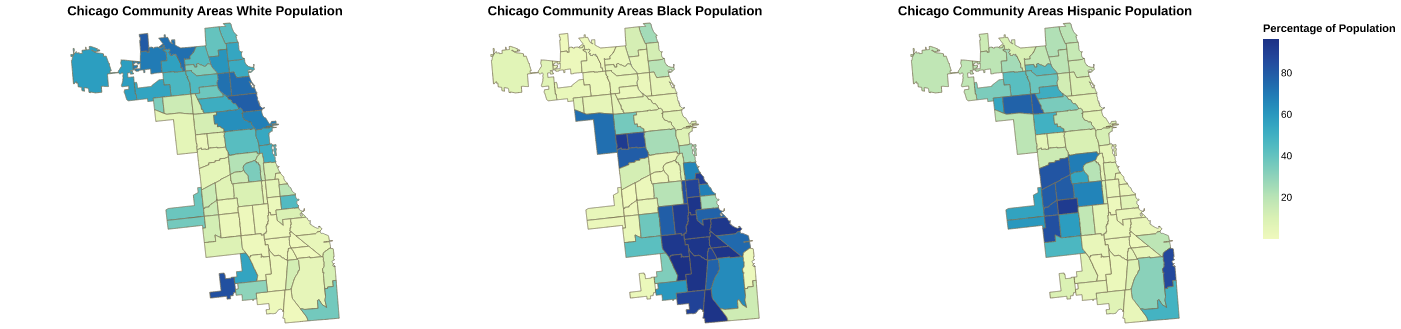

In [94]:
WhiteChicago_Chart=alt.Chart(
    mergeACS,
    title="Chicago Community Areas White Population").mark_geoshape( # '#2a1d0c',
    stroke='#706545',
    strokeWidth=0.75
).encode(
    alt.Color('PercentageWhite:Q',legend=alt.Legend(
            title="Percentage of Population"
        )),
    tooltip=[
        alt.Tooltip('community_area_name:N', title='CA'),
        alt.Tooltip('PercentageWhite:Q', title='White Population%')
    ]
).properties(
    width=400
).project(
    type='albers'
)

BlackChicago_Chart=alt.Chart(
    mergeACS,
    title="Chicago Community Areas Black Population").mark_geoshape( # '#2a1d0c',
    stroke='#706545',
    strokeWidth=0.75
).encode(
    alt.Color('PercentageBlack:Q'),
    tooltip=[
        alt.Tooltip('community_area_name:N', title='CA'),
        alt.Tooltip('PercentageBlack:Q', title='Black Population%')
    ]
).properties(
    width=400
).project(
    type='albers'
)

BlackChicago_Chart

HispanicChicago_Chart=alt.Chart(
    mergeACS,
    title="Chicago Community Areas Hispanic Population").mark_geoshape( # '#2a1d0c',
    stroke='#706545',
    strokeWidth=0.75
).encode(
    alt.Color('PercentageHispanic:Q'),
    tooltip=[
        alt.Tooltip('community_area_name:N', title='CA'),
        alt.Tooltip('PercentageHispanic:Q', title='Hispanic Population%')
    ]
).properties(
    width=400
).project(
    type='albers'
)

HispanicChicago_Chart

WhiteChicago_Chart | BlackChicago_Chart | HispanicChicago_Chart

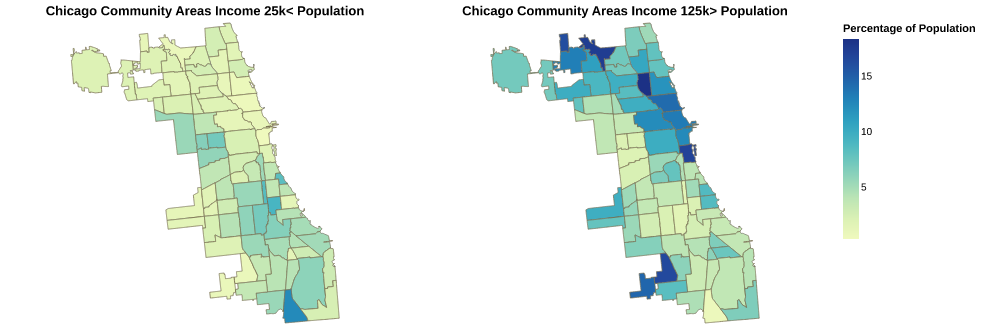

In [95]:
Income25k_Chart=alt.Chart(
    mergeACS,
    title="Chicago Community Areas Income 25k< Population").mark_geoshape( # '#2a1d0c',
    stroke='#706545',
    strokeWidth=0.75
).encode(
    alt.Color('Percentage<25k:Q',legend=alt.Legend(
            title="Percentage of Population"
        )),
    tooltip=[
        alt.Tooltip('community_area_name:N', title='CA'),
        alt.Tooltip('Percentage<25k:Q', title='%<25k'),
        alt.Tooltip('PercentageWhite:Q', title='White Population%'),
        alt.Tooltip('PercentageBlack:Q', title='Black Population%'),
        alt.Tooltip('PercentageHispanic:Q', title='HispanicPopulation%')
    ]
).properties(
    width=400
).project(
    type='albers'
)

Income25k_Chart

Income125k_Chart=alt.Chart(
    mergeACS,
    title="Chicago Community Areas Income 125k> Population").mark_geoshape( # '#2a1d0c',
    stroke='#706545',
    strokeWidth=0.75
).encode(
    alt.Color('Percentage>125k:Q',legend=alt.Legend(
            title="Percentage of Population"
        )),
    tooltip=[
        alt.Tooltip('community_area_name:N', title='CA'),
        alt.Tooltip('Percentage>125k:Q', title='%<25k'),
        alt.Tooltip('PercentageWhite:Q', title='White Population%'),
        alt.Tooltip('PercentageBlack:Q', title='Black Population%'),
        alt.Tooltip('PercentageHispanic:Q', title='HispanicPopulation%')
    ]
).properties(
    width=400
).project(
    type='albers'
)

Income25k_Chart | Income125k_Chart

In [96]:
acs.columns

Index(['ACS Year', 'community_area_name', 'Under $25,000',
       '$25,000 to $49,999', '$50,000 to $74,999', '$75,000 to $125,000',
       '$125,000 +', 'Male 0 to 17', 'Male 18 to 24', 'Male 25 to 34',
       'Male 35 to 49', 'Male 50 to 64', 'Male 65+', 'Female 0 to 17',
       'Female 18 to 24', 'Female 25 to 34', 'Female 35 to 49',
       'Female 50 to 64', 'Female 65 +', 'Total Population', 'White',
       'Black or African American', 'American Indian or Alaska Native',
       'Asian', 'Native Hawaiian or Pacific Islander', 'Other Race',
       'Multiracial', 'White Not Hispanic or Latino', 'Hispanic or Latino',
       'Record ID', 'PercentageWhite', 'PercentageBlack', 'PercentageHispanic',
       'Percentage<25k', 'Percentage>125k', 'PercentageCollegeAge'],
      dtype='object')

In [97]:
chicago_ca_df

,type,features,geometry,community_area,community_area_name
0,Feature,"{'type': 'Feature', 'geometry': {'type': 'Mult...","{'type': 'MultiPolygon', 'coordinates': [[[[-8...",1.0,ROGERS PARK
1,Feature,"{'type': 'Feature', 'geometry': {'type': 'Mult...","{'type': 'MultiPolygon', 'coordinates': [[[[-8...",2.0,WEST RIDGE
2,Feature,"{'type': 'Feature', 'geometry': {'type': 'Mult...","{'type': 'MultiPolygon', 'coordinates': [[[[-8...",3.0,UPTOWN
3,Feature,"{'type': 'Feature', 'geometry': {'type': 'Mult...","{'type': 'MultiPolygon', 'coordinates': [[[[-8...",4.0,LINCOLN SQUARE
4,Feature,"{'type': 'Feature', 'geometry': {'type': 'Mult...","{'type': 'MultiPolygon', 'coordinates': [[[[-8...",5.0,NORTH CENTER
...,...,...,...,...,...
72,Feature,"{'type': 'Feature', 'geometry': {'type': 'Mult...","{'type': 'MultiPolygon', 'coordinates': [[[[-8...",73.0,WASHINGTON HEIGHTS
73,Feature,"{'type': 'Feature', 'geometry': {'type': 'Mult...","{'type': 'MultiPolygon', 'coordinates': [[[[-8...",74.0,MOUNT GREENWOOD
74,Feature,"{'type': 'Feature', 'geometry': {'type': 'Mult...","{'type': 'MultiPolygon', 'coordinates': [[[[-8...",75.0,MORGAN PARK
75,Feature,"{'type': 'Feature', 'geometry': {'type': 'Mult...","{'type': 'MultiPolygon', 'coordinates': [[[[-8...",76.0,OHARE


In [98]:
# Build a name → number lookup
name_to_num = (chicago_ca_df[['community_area_name', 'community_area']]
               .assign(area_numbe=lambda d: d['community_area'].astype(int))
               .set_index('community_area_name')['community_area']
               .to_dict())

print(f"Found {len(name_to_num)} community area mappings")
print({k: name_to_num[k] for k in list(name_to_num)[:5]})  # peek at first 5

Found 77 community area mappings
{'ROGERS PARK': 1.0, 'WEST RIDGE': 2.0, 'UPTOWN': 3.0, 'LINCOLN SQUARE': 4.0, 'NORTH CENTER': 5.0}


In [99]:
acs['community_area']=acs['community_area_name'].map(name_to_num)
#acs

In [100]:
demographics=acs[['PercentageWhite', 'PercentageBlack', 'PercentageHispanic',
       'Percentage<25k', 'Percentage>125k', 'PercentageCollegeAge','community_area', "community_area_name"]]
demographics

,PercentageWhite,PercentageBlack,PercentageHispanic,Percentage<25k,Percentage>125k,PercentageCollegeAge,community_area,community_area_name
0,33.692243,4.658164,44.131298,2.653147,7.064604,11.206356,14.0,ALBANY PARK
1,14.724324,0.072072,79.978378,1.607207,5.326126,11.754955,57.0,ARCHER HEIGHTS
2,16.929044,11.308845,4.296905,5.331204,4.540269,7.635562,34.0,ARMOUR SQUARE
3,8.809113,42.304281,46.489426,1.860324,6.383922,9.831474,70.0,ASHBURN
4,1.056300,93.397586,3.392638,5.466515,3.979950,8.906482,71.0,AUBURN GRESHAM
...,...,...,...,...,...,...,...,...
72,12.264645,2.862778,84.049798,2.360482,5.475948,10.877939,65.0,WEST LAWN
73,1.148694,89.137088,7.377082,5.485115,4.602727,10.179260,53.0,WEST PULLMAN
74,39.745014,11.752083,22.129513,2.635698,6.724312,7.304973,2.0,WEST RIDGE
75,63.045817,6.985298,19.778377,1.215689,12.333869,6.712318,24.0,WEST TOWN


In [101]:
pickupdemographics=pickupresiduals.merge(demographics, on='community_area')
dropoffdemographics=dropoffresiduals.merge(demographics, on='community_area')

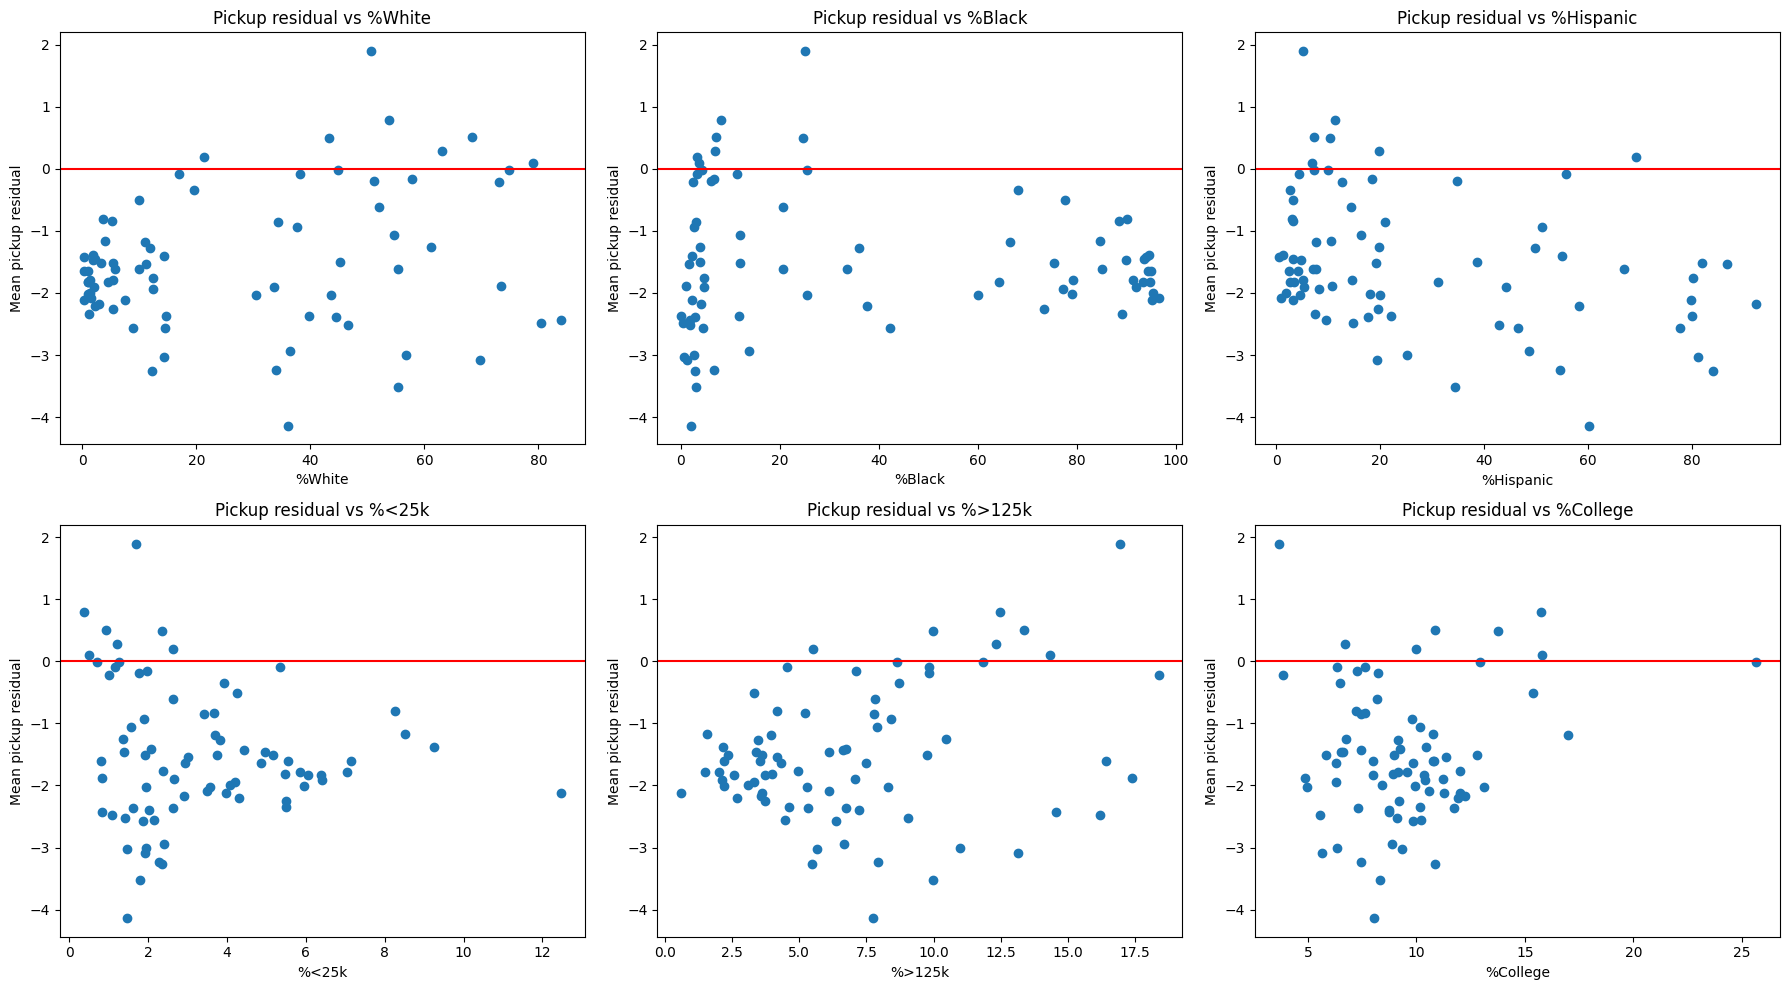

In [102]:
fig, axes = plt.subplots(2,3,figsize=(18,10))
variables=['PercentageWhite', 'PercentageBlack', 'PercentageHispanic',
       'Percentage<25k', 'Percentage>125k', 'PercentageCollegeAge']
titles=['%White', '%Black', '%Hispanic', '%<25k', '%>125k', '%College']

for ax, var, title in zip(axes.flatten(),variables,titles):
  ax.scatter(pickupdemographics[var],pickupdemographics['mean_total'],label='Pickup')
  ax.axhline(0,color='red')
  ax.set_xlabel(title)
  ax.set_ylabel("Mean pickup residual")
  ax.set_title(f"Pickup residual vs {title}")

plt.tight_layout()
plt.show()

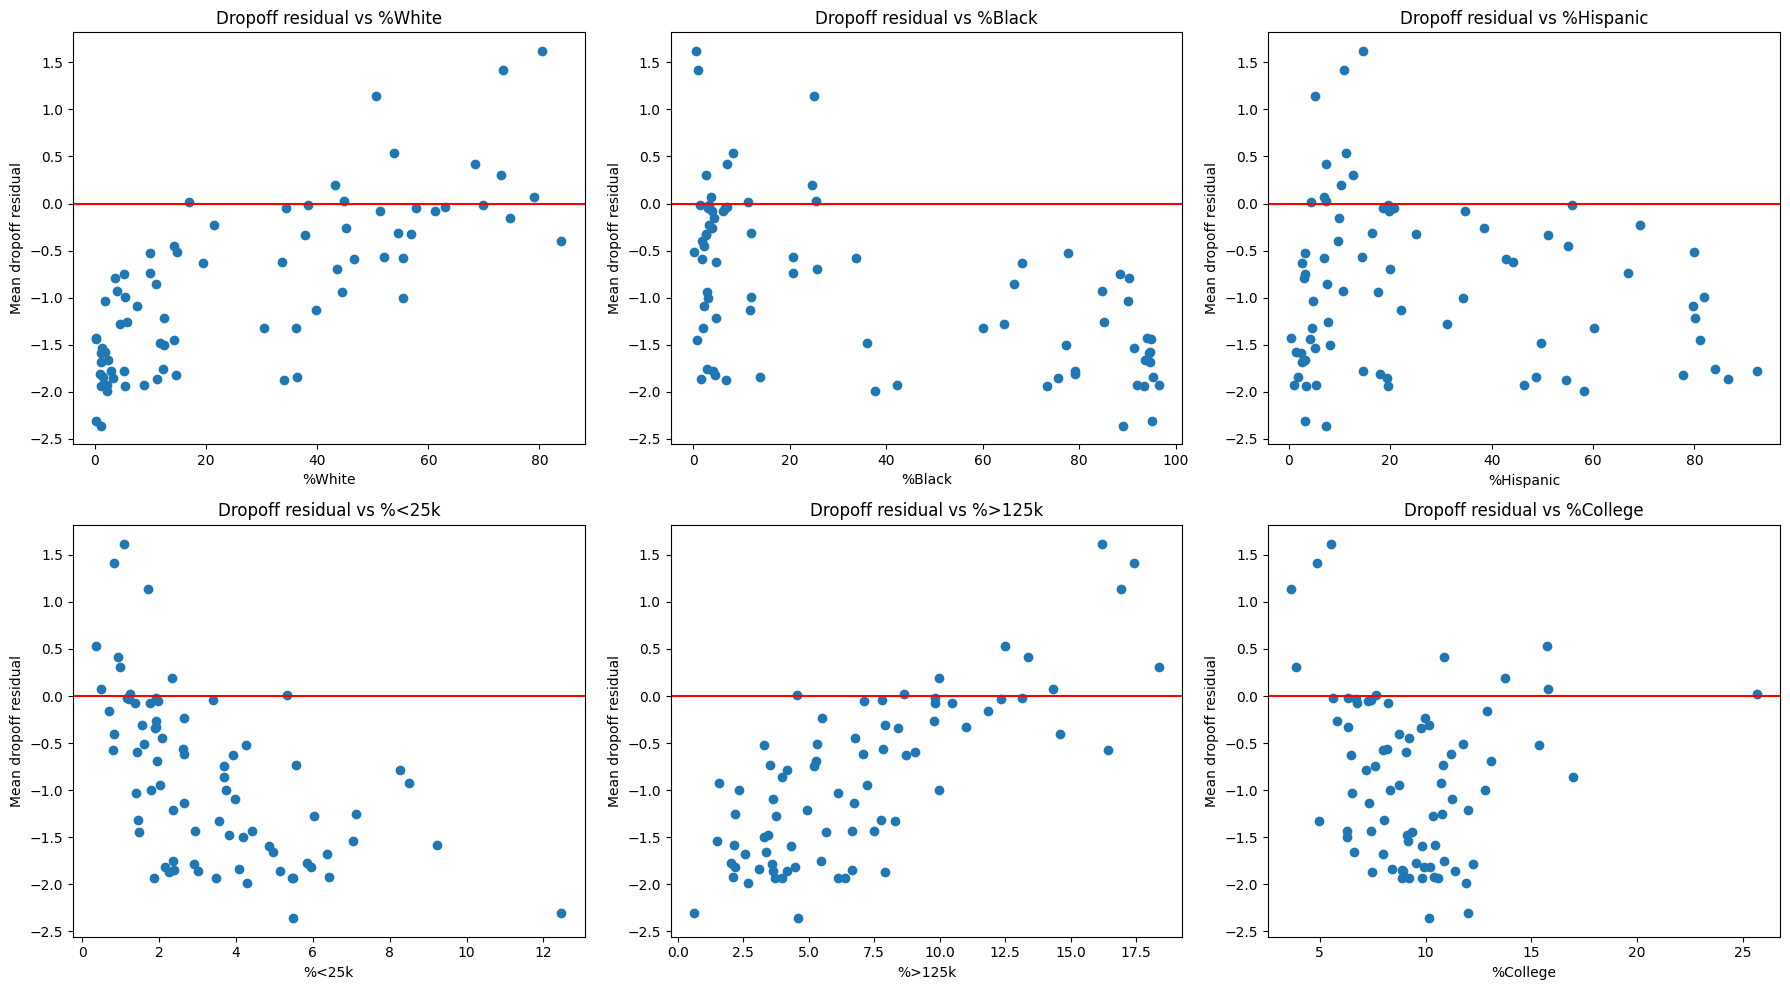

In [103]:
fig, axes = plt.subplots(2,3,figsize=(18,10))
variables=['PercentageWhite', 'PercentageBlack', 'PercentageHispanic',
       'Percentage<25k', 'Percentage>125k', 'PercentageCollegeAge']
titles=['%White', '%Black', '%Hispanic', '%<25k', '%>125k', '%College']

for ax, var, title in zip(axes.flatten(),variables,titles):
  ax.scatter(dropoffdemographics[var],dropoffdemographics['mean_total'],label='Dropoff')
  ax.axhline(0,color='red')
  ax.set_xlabel(title)
  ax.set_ylabel("Mean dropoff residual")
  ax.set_title(f"Dropoff residual vs {title}")

plt.tight_layout()
plt.show()

- As percentage of white increases the mean drropoff residual increases. Saying that more whites the model underpredicts, underprices. The actual value is higher.
- As the percentage of black people increase the model has a negative residual meaning the data model's prediction is too high compared to the actual value. The actual value is lower.

In [104]:
print("PICKUP correlations with mean residual:")
for var in ['PercentageWhite', 'PercentageBlack', 'PercentageHispanic',
            'Percentage<25k', 'Percentage>125k', 'PercentageCollegeAge']:
    r_p = pickupdemographics[[var, 'mean_total']].corr().iloc[0, 1]
    r_s = pickupdemographics[[var, 'mean_total']].corr(method='spearman').iloc[0, 1]
    print(f"  {var:25s}  Pearson r = {r_p:+.3f},  Spearman r = {r_s:+.3f}")

print("DROPOFF correlations with mean residual:")
for var in ['PercentageWhite', 'PercentageBlack', 'PercentageHispanic',
            'Percentage<25k', 'Percentage>125k', 'PercentageCollegeAge']:
    r_p = dropoffdemographics[[var, 'mean_total']].corr().iloc[0, 1]
    r_s = dropoffdemographics[[var, 'mean_total']].corr(method='spearman').iloc[0, 1]
    print(f"  {var:25s}  Pearson r = {r_p:+.3f},  Spearman r = {r_s:+.3f}")

PICKUP correlations with mean residual:
  PercentageWhite            Pearson r = +0.231,  Spearman r = +0.173
  PercentageBlack            Pearson r = -0.026,  Spearman r = +0.151
  PercentageHispanic         Pearson r = -0.333,  Spearman r = -0.320
  Percentage<25k             Pearson r = -0.109,  Spearman r = -0.101
  Percentage>125k            Pearson r = +0.285,  Spearman r = +0.181
  PercentageCollegeAge       Pearson r = +0.147,  Spearman r = +0.047
DROPOFF correlations with mean residual:
  PercentageWhite            Pearson r = +0.768,  Spearman r = +0.774
  PercentageBlack            Pearson r = -0.554,  Spearman r = -0.528
  PercentageHispanic         Pearson r = -0.159,  Spearman r = +0.012
  Percentage<25k             Pearson r = -0.557,  Spearman r = -0.639
  Percentage>125k            Pearson r = +0.770,  Spearman r = +0.711
  PercentageCollegeAge       Pearson r = -0.096,  Spearman r = -0.190


Pickup correlations are weak but dropoff correlations are pretty high.

In [105]:
import numpy as np

def weighted_corr(df, x_col, y_col, w_col):
    w = df[w_col].values
    x = df[x_col].values
    y = df[y_col].values
    wm_x = np.average(x, weights=w)
    wm_y = np.average(y, weights=w)
    cov_xy = np.average((x - wm_x) * (y - wm_y), weights=w)
    var_x = np.average((x - wm_x)**2, weights=w)
    var_y = np.average((y - wm_y)**2, weights=w)
    return cov_xy / np.sqrt(var_x * var_y)

print("Trip-volume-weighted correlations (pickup):")
for var in ['PercentageWhite', 'PercentageBlack', 'Percentage<25k', 'Percentage>125k']:
    r = weighted_corr(pickupdemographics, var, 'mean_total', 'count')
    print(f"  {var:25s} {r:+.3f}")

print("Trip-volume-weighted correlations (dropoff):")
for var in ['PercentageWhite', 'PercentageBlack', 'Percentage<25k', 'Percentage>125k']:
    r = weighted_corr(dropoffdemographics, var, 'mean_total', 'count')
    print(f"  {var:25s} {r:+.3f}")

  #decided to weight to see if it changes anything for pickup, it does

Trip-volume-weighted correlations (pickup):
  PercentageWhite           +0.545
  PercentageBlack           -0.443
  Percentage<25k            -0.594
  Percentage>125k           +0.739
Trip-volume-weighted correlations (dropoff):
  PercentageWhite           +0.662
  PercentageBlack           -0.651
  Percentage<25k            -0.737
  Percentage>125k           +0.818


In [106]:
# For each trip, attach the pickup community area demographics
trip_demo = df3.merge(demographics[['community_area', 'PercentageWhite', 'Percentage<25k']],
                      left_on='Pickup Community Area',
                      right_on='community_area', how='left')

# Compare by hardship/wealth split
trip_demo['white_majority'] = trip_demo['PercentageWhite'] > 50

print(trip_demo.groupby('white_majority').agg(
    avg_miles=('Trip Miles', 'mean'),
    avg_minutes=('Trip Minutes', 'mean'),
    avg_fare=('Fare', 'mean'),
    n_trips=('Fare', 'size'),
))

                avg_miles  avg_minutes   avg_fare  n_trips
white_majority                                            
False             4.77702    14.774781  13.150237  1180093
True              4.35805    13.895875  13.902764  2571290


uneven number of trips in white neighborhoods vs non-white neighborhoods.

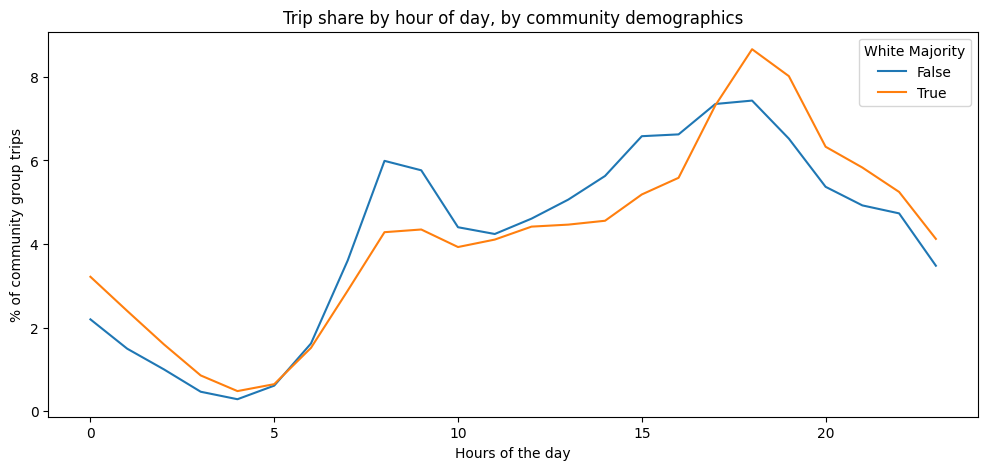

In [107]:
trip_demo['hour'] = pd.to_datetime(trip_demo['Trip Start Timestamp']).dt.hour

hour_dist = trip_demo.groupby(['white_majority', 'hour']).size().unstack(0)
hour_dist_pct = hour_dist.div(hour_dist.sum()) * 100

import matplotlib.pyplot as plt
hour_dist_pct.plot(figsize=(12, 5))
plt.title('Trip share by hour of day, by community demographics')
plt.legend(title="White Majority")
plt.xlabel('Hours of the day')
plt.ylabel('% of community group trips')
plt.show()

- By looking at this we can say in white areas people use shorter rides, less miles but charged higher, because they use it during surge pricing. White areas use rideshare disproportiantely during surge times.
- User driven, drive more during expensive hour sin wealthier neighborhoods
- surge pricing, wealthy riders pay more  